<div style="background: linear-gradient(90deg, #ff7e5f, #feb47b, #86A8E7, #91EAE4); 
            padding: 25px; 
            border-radius: 15px; 
            text-align: center;
            box-shadow: 3px 3px 15px rgba(0,0,0,0.2);">
    <h1 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Digital Image Processing
    </h1>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Topic: Noise and Its Types
    </h3>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Notebook by - Himel Sarder
    </h3>
    <p style="font-family: 'Verdana', sans-serif; color: #ffffffcc; font-size: 16px; text-align: center">
        info.himelcse@gmail.com
    </p>
</div>

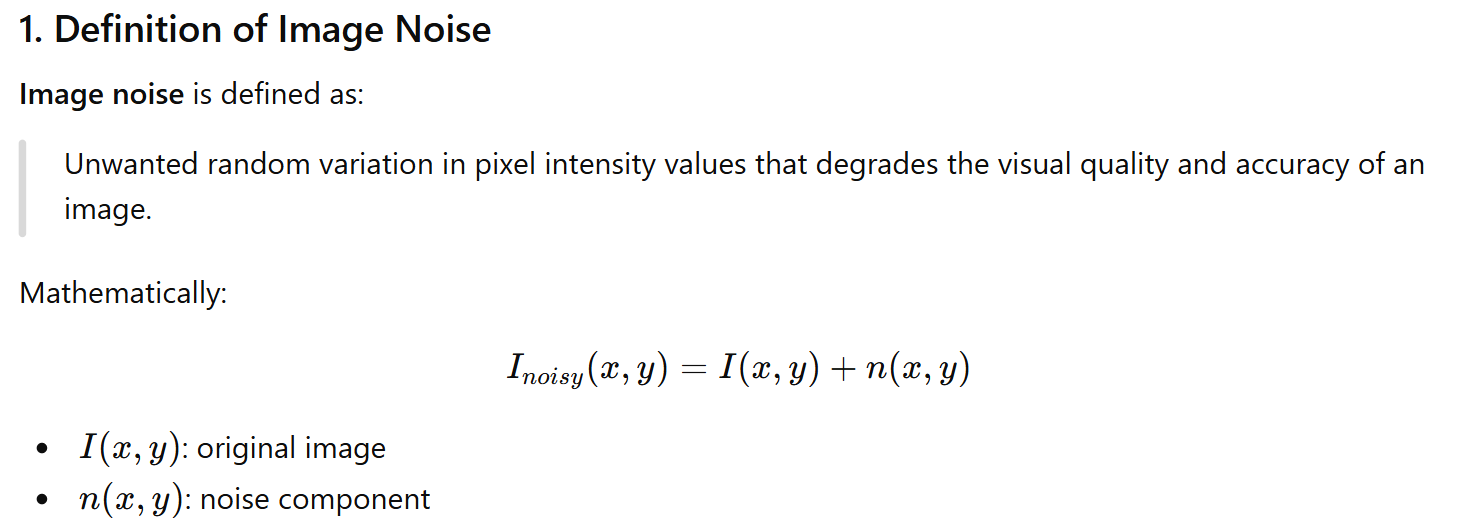
# 2. Types of Noise
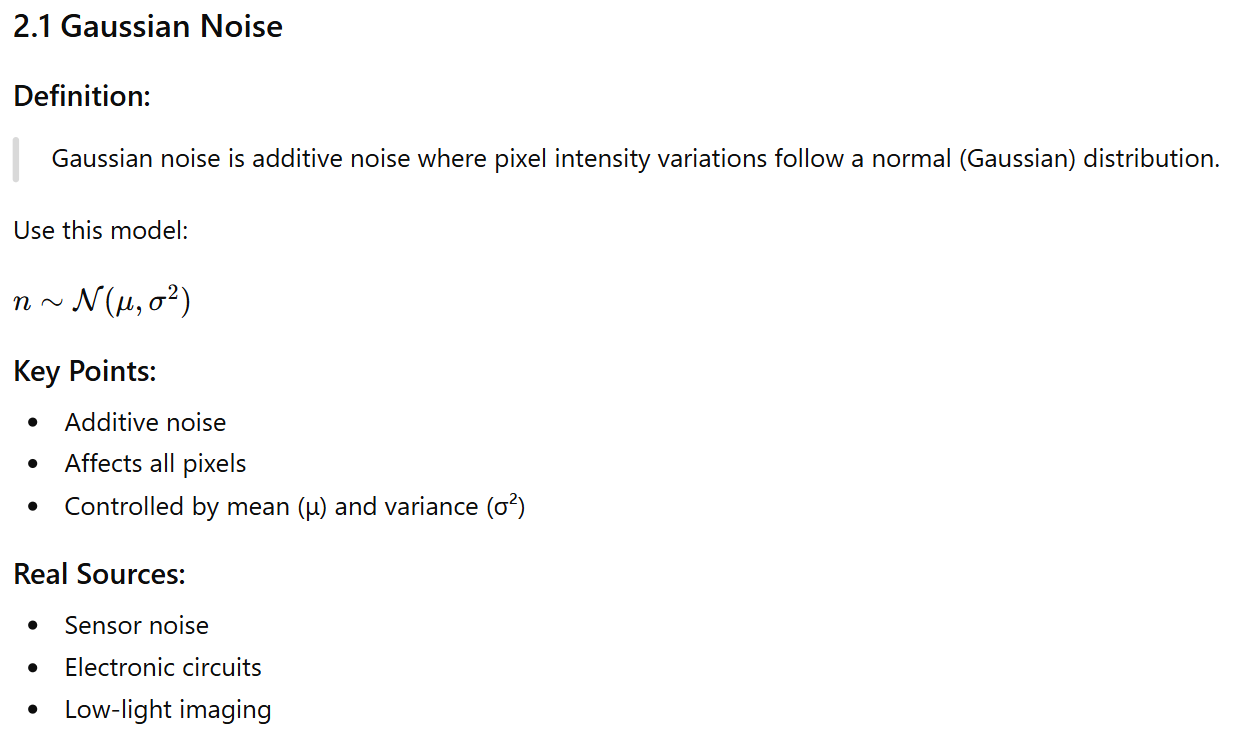

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

def add_gaussian_noise(img, mean=0, sigma=25):
    img = img.astype(np.float32)
    # Images are usually in uint8 (values 0–255)
    # Adding noise may create values < 0 or > 255
    # So we convert to float for safe calculations
    
    noise = np.random.normal(mean, sigma, img.shape)
    # Creates random noise using a Gaussian (normal) distribution
    # mean = 0 → noise centered around 0
    # sigma = 25 → controls how strong the noise is
    # img.shape → noise has the same size as the image
    
    noisy = img + noise
    # Adds random variation to each pixel
    # Result = noisy image
    
    noisy = np.clip(noisy, 0, 255)
    # Ensures all values stay within valid image range (0–255)
    # Prevents overflow or negative values
    
    return noisy.astype(np.uint8)
    # Converts image back to standard format for display/storage
gaussian = add_gaussian_noise(image)

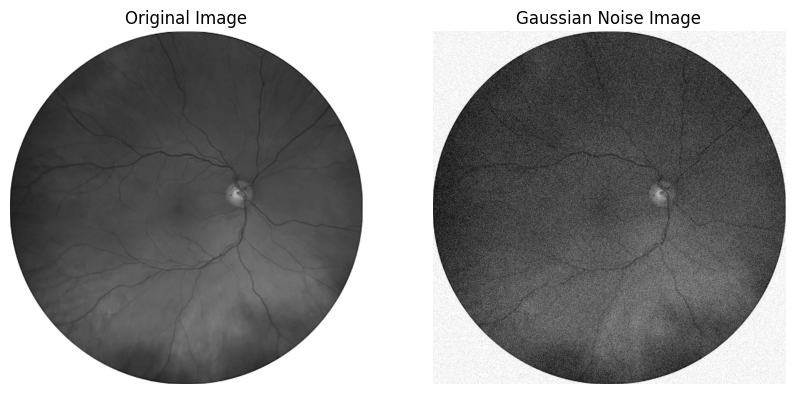

In [9]:
# Display using matplotlib
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gaussian, cmap='gray')
plt.title('Gaussian Noise Image')
plt.axis('off')

plt.show()

## Using Skimage

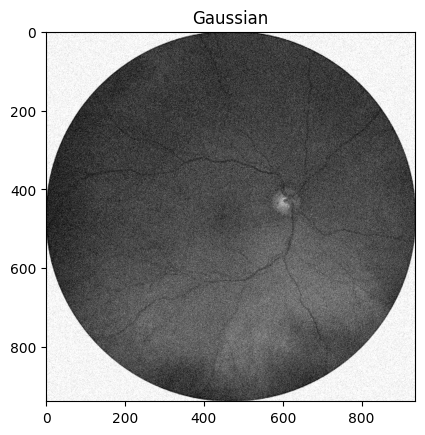

In [7]:
from skimage.util import random_noise

gaussian = random_noise(image, mode='gaussian')

plt.imshow(gaussian, cmap='gray')
plt.title('Gaussian')

plt.show()

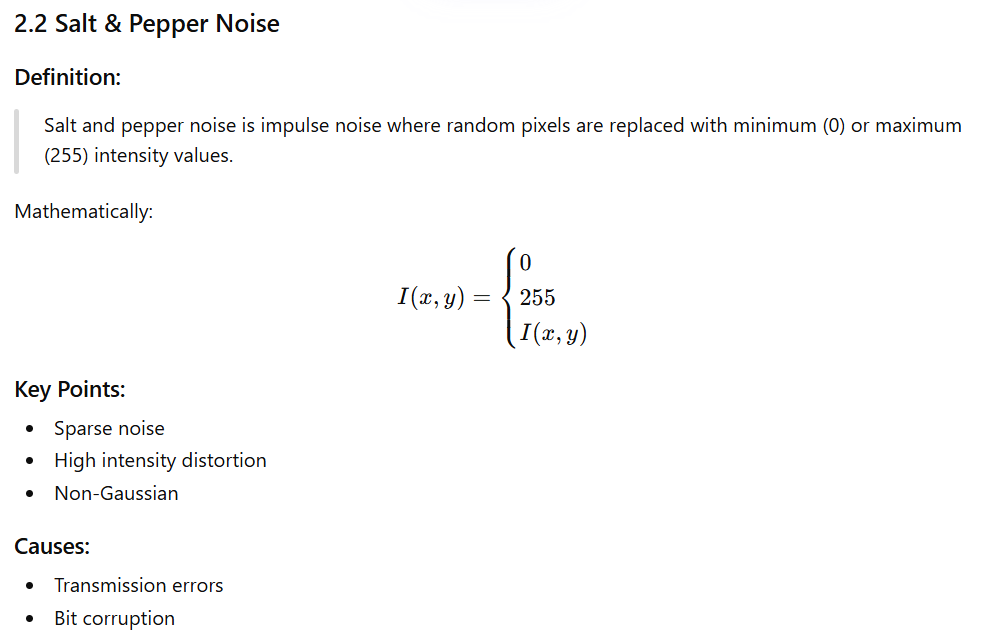

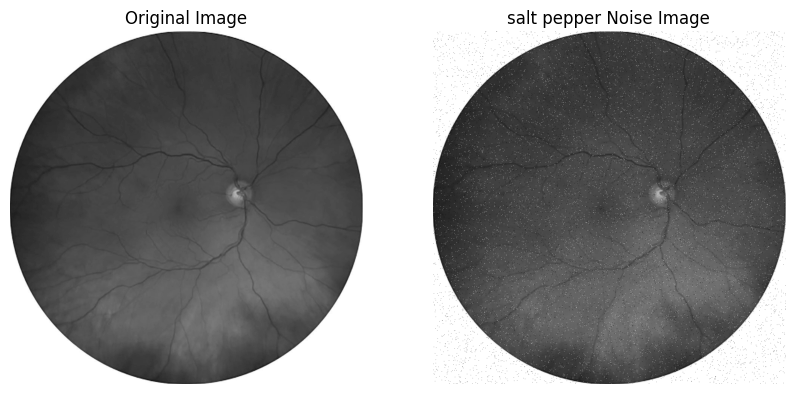

In [10]:
def add_salt_pepper(img, prob=0.02):
    noisy = img.copy()
    h, w = img.shape

    num_pixels = int(prob * h * w)

    for _ in range(num_pixels // 2):
        x = np.random.randint(0, h)
        y = np.random.randint(0, w)
        noisy[x, y] = 255

    for _ in range(num_pixels // 2):
        x = np.random.randint(0, h)
        y = np.random.randint(0, w)
        noisy[x, y] = 0

    return noisy

sp = add_salt_pepper(image)

# Display using matplotlib
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sp, cmap='gray')
plt.title('salt pepper Noise Image')
plt.axis('off')

plt.show()

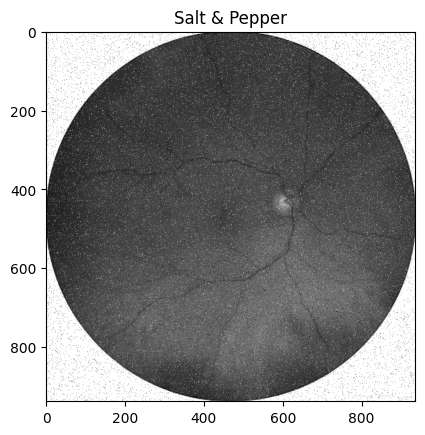

In [11]:
import cv2
import matplotlib.pyplot as plt
from skimage.util import random_noise

image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

sp = random_noise(image, mode='s&p')

plt.imshow(sp, cmap='gray')
plt.title('Salt & Pepper')

plt.show()

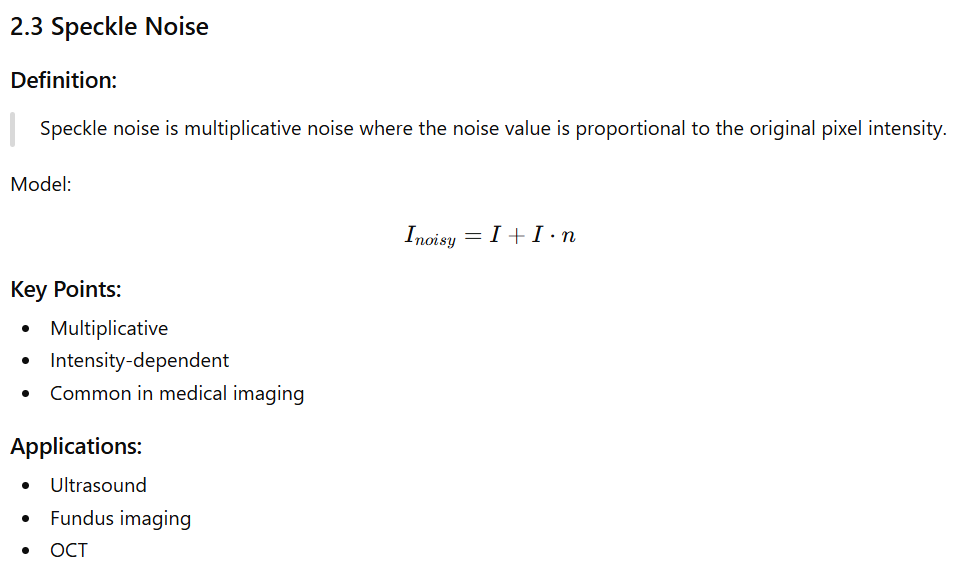

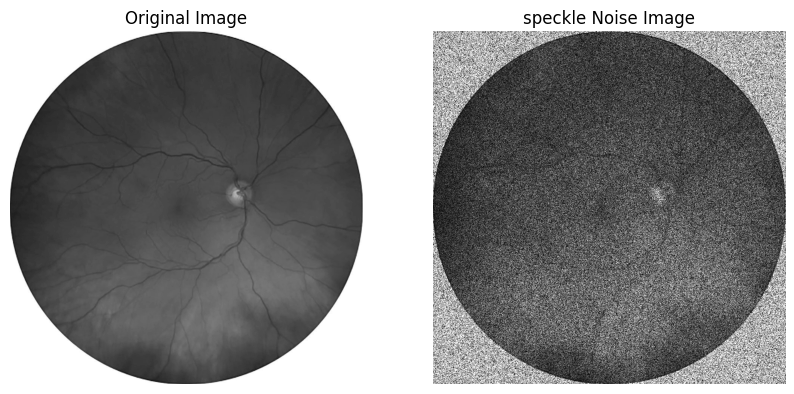

In [14]:
def add_speckle(img):
    img = img.astype(np.float32) / 255.0
    # Converts pixel values from 0–255 → 0–1
    # Needed because noise operations are easier and safer in this range
    
    noise = np.random.randn(*img.shape)
    noisy = img + img * noise
    # Noise is multiplied with the image
    # So brighter pixels get more noise
    # Dark pixels get less noise

    noisy = np.clip(noisy, 0, 1)
    return (noisy * 255).astype(np.uint8)

speckle = add_speckle(image)

# Display using matplotlib
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(speckle, cmap='gray')
plt.title('speckle Noise Image')
plt.axis('off')

plt.show()

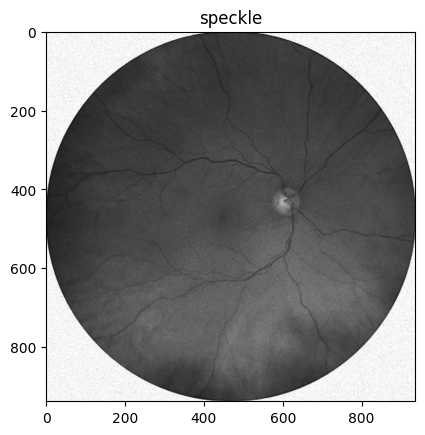

In [13]:
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

spski = random_noise(image, mode='speckle')

plt.imshow(spski, cmap='gray')
plt.title('speckle')

plt.show()

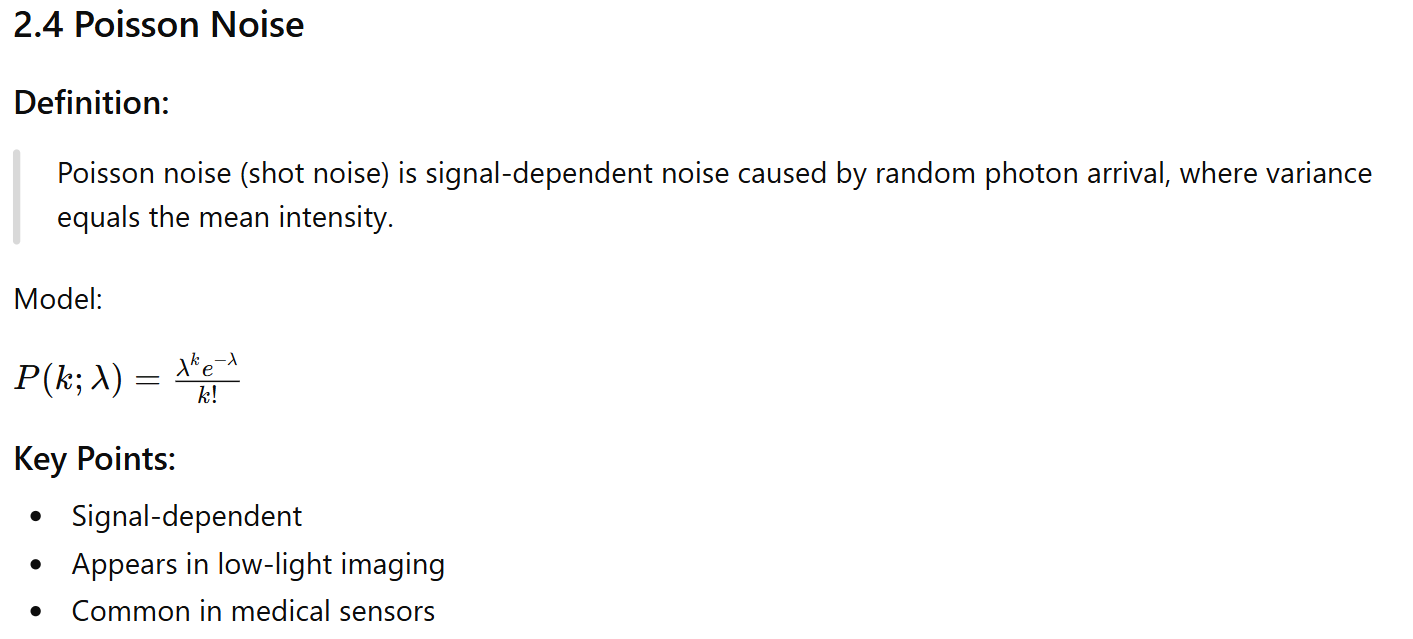

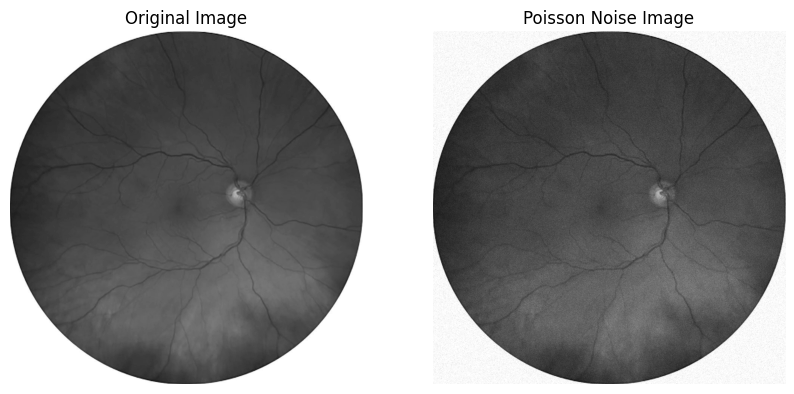

In [15]:
def add_poisson(img):
    img = img.astype(np.float32)
    noisy = np.random.poisson(img)
    noisy = np.clip(noisy, 0, 255)
    return noisy.astype(np.uint8)

poisson = add_poisson(image)

# Display using matplotlib
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(poisson, cmap='gray')
plt.title('Poisson Noise Image')
plt.axis('off')

plt.show()

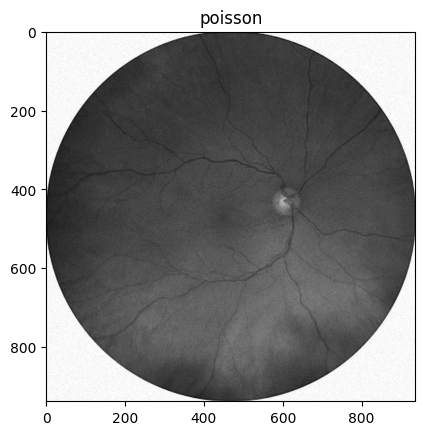

In [16]:
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)

poissonsk = random_noise(image, mode='poisson')

plt.imshow(poissonsk, cmap='gray')
plt.title('poisson')

plt.show()

| Noise Type    | Definition Type | Behavior              |
| ------------- | --------------- | --------------------- |
| Gaussian      | Additive        | Affects all pixels    |
| Salt & Pepper | Impulse         | Random extreme pixels |
| Speckle       | Multiplicative  | Depends on intensity  |
| Poisson       | Statistical     | Photon-based          |